In [3]:
import splitfolders
splitfolders.ratio(r"D:\ZSL\devise-Awa2-october-2022\Balanced_AWA2_123_dataset_complete_primary", 'split_data', seed=1111, ratio=(0.7, 0.15, 0.15))

In [1]:
import splitfolders
splitfolders.ratio(r"D:\ZSL\devise-Awa2-october-2022\Balanced_Primary_dataset_1_Jan_2024", 'split_data', seed=1111, ratio=(0.7, 0.15, 0.15))

In [1]:
import numpy as np
import urllib.request
from gensim.utils import simple_preprocess
import os, re

# # Download GloVe embeddings
# glove_url = "http://nlp.stanford.edu/data/glove.6B.zip"
# urllib.request.urlretrieve(glove_url, "glove.6B.zip")

# import zipfile
# with zipfile.ZipFile("glove.6B.zip", "r") as zip_ref:
#      zip_ref.extractall("glove.6B")

In [50]:
#encoder.save(os.path.join(model_folder_path, 'complete_encoder_model_7th_august_2024.h5'))
#autoencoder.save(os.path.join(model_folder_path, 'complete_autoencoder_model_7th_august_2024.h5'))

custom_sentences = ['blue whale', 'bobcat', 'cow', 'dolphin', 
                     'gorilla', 'killer whale', 'lion', 'mouse', 'ox', 'polar_bear', 'rabbit', 
                     'rhinoceros', 'siamese cat', 'skunk', 'monkey', 'squirrel', 'tiger', 'walrus',
                     'chimp', 'chimpanzee', 'giant panda', 'hippopotamus', 'humpback whale', 'leopard',
                'persian cat', 'pig', 'raccoon', 'rat', 'seal','cat','whale']


custom_sentences = ['whale', 'bobcat', 'cow', 'dolphin', 
                     'gorilla', 'lion', 'mouse', 'ox', 'polar_bear', 'rabbit', 
                     'rhinoceros', 'skunk', 'monkey', 'squirrel', 'tiger', 'walrus',
                     'chimp', 'chimpanzee', 'giant panda', 'hippopotamus', 'humpback whale', 'leopard',
                'persian cat', 'pig', 'raccoon', 'rat', 'seal','cat','whale']

In [2]:
# Example custom dataset
custom_sentences = ['blue whale', 'bobcat', 'cow', 'dolphin', 
                     'gorilla', 'killer whale', 'lion', 'mouse', 'ox', 'polar_bear', 'rabbit', 
                     'rhinoceros', 'siamese cat', 'skunk', 'monkey', 'squirrel', 'tiger', 'walrus',
                     'chimp', 'chimpanzee', 'giant panda', 'hippopotamus', 'humpback whale', 'leopard',
                'persian cat', 'pig', 'raccoon', 'rat', 'seal','cat','whale']

# animals_list_file_path = os.path.join('..', 'Dataset', 'artefact1', 'animals.txt')
# with open(animals_list_file_path, "r") as f:
#custom_sentences = [line[:-1] for line in f]

# Load GloVe embeddings
def load_glove_embeddings(file_path):
    embeddings_index = {}
    with open(file_path, 'r', encoding='utf8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    return embeddings_index

embeddings_index = load_glove_embeddings("glove.6B/glove.6B.300d.txt")  # Using 50d GloVe embeddings
print(f"embeddings_index : {type(embeddings_index)} \n")

# Convert sentences to embeddings
def sentence_to_embedding(sentence, embeddings_index):
    words = simple_preprocess(sentence)
    valid_words = [embeddings_index[word] for word in words if word in embeddings_index]
    if valid_words:
        return np.mean(valid_words, axis=0)
    else:
        return np.zeros(300) # Using 50d GloVe embeddings

sentence_embeddings = np.array([sentence_to_embedding(sentence, embeddings_index) for sentence in custom_sentences])
print(f"sentence_embeddings : {type(sentence_embeddings)} \n")

embeddings_index : <class 'dict'> 

sentence_embeddings : <class 'numpy.ndarray'> 



In [5]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Define the size of the input and latent space
input_dim = 300 # 50  # Dimension of GloVe embeddings
latent_dim = 16  # Dimension of latent space

# Input layer
input_layer = Input(shape=(input_dim,))

# Sample Test 1
# Encoder layers
encoded = Dense(32, activation='relu')(input_layer)
encoded = Dense(latent_dim, activation='relu')(encoded)

# Decoder layers
decoded = Dense(32, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

# # Sample Test 2
# # Encoder layers
# encoded = Dense(latent_dim * 4, activation='relu')(input_layer)
# encoded = Dropout(0.2)(encoded)
# encoded = Dense(latent_dim * 2, activation='relu')(encoded)
# encoded = Dropout(0.2)(encoded)
# encoded = Dense(latent_dim, activation='relu')(encoded)

# # Decoder layers
# decoded = Dense(latent_dim * 2, activation='relu')(encoded)
# decoded = Dropout(0.2)(decoded)
# decoded = Dense(latent_dim * 4, activation='relu')(decoded)
# decoded = Dropout(0.2)(decoded)
# decoded = Dense(input_dim, activation='sigmoid')(decoded)

# # Sample Test 3
# # Encoder layers
# encoded = Dense(latent_dim * 4, activation='relu')(input_layer)
# encoded = Dense(latent_dim * 2, activation='relu')(encoded)
# encoded = Dense(latent_dim, activation='relu')(encoded)

# # Decoder layers
# decoded = Dense(latent_dim * 2, activation='relu')(encoded)
# decoded = Dense(latent_dim * 4, activation='relu')(decoded)
# decoded = Dense(input_dim, activation='sigmoid')(decoded)

# # Sample Test 4
# # Encoder layers
# encoded = Dense(latent_dim * 16, activation='relu')(input_layer)
# encoded = Dense(latent_dim * 8, activation='relu')(encoded)
# encoded = Dense(latent_dim * 4, activation='relu')(encoded)
# encoded = Dense(latent_dim * 2, activation='relu')(encoded)
# encoded = Dense(latent_dim, activation='relu')(encoded)

# # Decoder layers
# decoded = Dense(latent_dim * 2, activation='relu')(encoded)
# decoded = Dense(latent_dim * 4, activation='relu')(decoded)
# decoded = Dense(latent_dim * 8, activation='relu')(decoded)
# decoded = Dense(latent_dim * 16, activation='relu')(decoded)
# decoded = Dense(input_dim, activation='sigmoid')(decoded)

# Autoencoder model
autoencoder = Model(input_layer, decoded)

# Encoder model
encoder = Model(input_layer, encoded)

# Compile the autoencoder
autoencoder.compile(optimizer='adam', loss='mse')
# autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')


In [4]:
encoder.summary() 

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 300)]             0         
                                                                 
 dense (Dense)               (None, 32)                9632      
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
Total params: 10,160
Trainable params: 10,160
Non-trainable params: 0
_________________________________________________________________


In [5]:
autoencoder.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 300)]             0         
                                                                 
 dense (Dense)               (None, 32)                9632      
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
 dense_2 (Dense)             (None, 32)                544       
                                                                 
 dense_3 (Dense)             (None, 300)               9900      
                                                                 
Total params: 20,604
Trainable params: 20,604
Non-trainable params: 0
_________________________________________________________________


In [4]:
from tensorflow.keras.callbacks import EarlyStopping

# Define the early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',     # Monitor the validation loss
    patience=10,            # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True  # Restore model weights from the epoch with the best value of the monitored quantity
)

# Train the autoencoder with early stopping
autoencoder.fit(
    sentence_embeddings, 
    sentence_embeddings, 
    epochs=500, 
    batch_size=32, 
    shuffle=True, 
    validation_split=0.1, 
    callbacks=[early_stopping]
)


Epoch 1/500
1/1 [==============================] - 2s 2s/step - loss: 0.3820 - val_loss: 0.4027
Epoch 2/500
1/1 [==============================] - 0s 56ms/step - loss: 0.3810 - val_loss: 0.4016
Epoch 3/500
1/1 [==============================] - 0s 55ms/step - loss: 0.3801 - val_loss: 0.4004
Epoch 4/500
1/1 [==============================] - 0s 53ms/step - loss: 0.3790 - val_loss: 0.3992
Epoch 5/500
1/1 [==============================] - 0s 55ms/step - loss: 0.3777 - val_loss: 0.3977
Epoch 6/500
1/1 [==============================] - 0s 53ms/step - loss: 0.3763 - val_loss: 0.3961
Epoch 7/500
1/1 [==============================] - 0s 57ms/step - loss: 0.3747 - val_loss: 0.3942
Epoch 8/500
1/1 [==============================] - 0s 55ms/step - loss: 0.3729 - val_loss: 0.3919
Epoch 9/500
1/1 [==============================] - 0s 57ms/step - loss: 0.3709 - val_loss: 0.3894
Epoch 10/500
1/1 [==============================] - 0s 56ms/step - loss: 0.3685 - val_loss: 0.3866
Epoch 11/500
1/1 [===

In [6]:
# Train the autoencoder
autoencoder.fit(sentence_embeddings, sentence_embeddings, epochs=250, batch_size=32, shuffle=True, validation_split=0.1)

Epoch 1/250
1/1 [==============================] - 3s 3s/step - loss: 0.3824 - val_loss: 0.4026
Epoch 2/250
1/1 [==============================] - 0s 56ms/step - loss: 0.3810 - val_loss: 0.4011
Epoch 3/250
1/1 [==============================] - 0s 50ms/step - loss: 0.3795 - val_loss: 0.3994
Epoch 4/250
1/1 [==============================] - 0s 64ms/step - loss: 0.3780 - val_loss: 0.3976
Epoch 5/250
1/1 [==============================] - 0s 53ms/step - loss: 0.3764 - val_loss: 0.3956
Epoch 6/250
1/1 [==============================] - 0s 60ms/step - loss: 0.3745 - val_loss: 0.3934
Epoch 7/250
1/1 [==============================] - 0s 51ms/step - loss: 0.3724 - val_loss: 0.3909
Epoch 8/250
1/1 [==============================] - 0s 59ms/step - loss: 0.3700 - val_loss: 0.3880
Epoch 9/250
1/1 [==============================] - 0s 58ms/step - loss: 0.3673 - val_loss: 0.3848
Epoch 10/250
1/1 [==============================] - 0s 65ms/step - loss: 0.3642 - val_loss: 0.3811
Epoch 11/250
1/1 [===

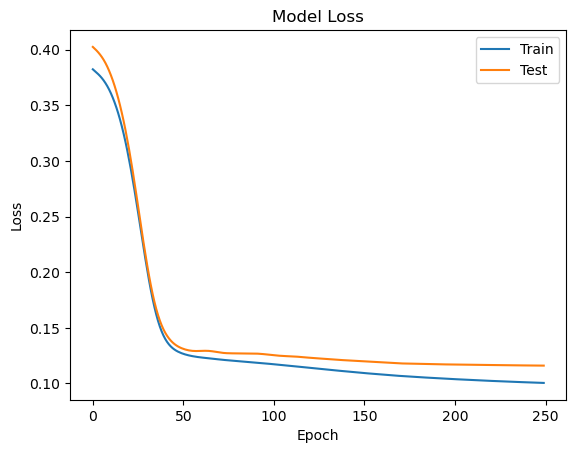

In [7]:
import matplotlib.pyplot as plt
import os

image_name = 'complete_autoencoder_training_7th_august_2024.png'
# Update the path to the desired location
image_folder_path = os.path.join('D:\\', 'ZSL', 'CNN', 'result_image')
image_path = os.path.join(image_folder_path, image_name)

# Create the directory if it doesn't exist
os.makedirs(image_folder_path, exist_ok=True)

# Summarize history for loss
plt.plot(autoencoder.history.history['loss'])
plt.plot(autoencoder.history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper right')

# Save the figure
plt.savefig(image_path, bbox_inches='tight')
plt.show()


In [6]:
# Encode sentences to get their latent representations
sentence_latents = encoder.predict(sentence_embeddings)
# print(f"sentence_latents : {sentence_latents}")

# Create a dictionary to map sentences to their latent representations
sentence_to_latent = {i: sentence_latents[i] for i in range(len(custom_sentences))}
# print(f"sentence_to_latent : {sentence_to_latent}")

1/1 [==============================] - 0s 85ms/step


In [30]:
custom_sentences.index('tiger')

16

In [11]:
print(custom_sentences, '\n')
print(sentence_to_latent[1], custom_sentences[10])  # index starts from 0 

['blue whale', 'bobcat', 'cow', 'dolphin', 'gorilla', 'killer whale', 'lion', 'mouse', 'ox', 'polar_bear', 'rabbit', 'rhinoceros', 'siamese cat', 'skunk', 'monkey', 'squirrel', 'tiger', 'walrus', 'chimp', 'chimpanzee', 'giant panda', 'hippopotamus', 'humpback whale', 'leopard', 'persian cat', 'pig', 'raccoon', 'rat', 'seal', 'cat', 'whale'] 

[3.0456729e+00 1.0908027e+00 5.6038680e+00 6.0397210e+00 0.0000000e+00
 5.1449022e+00 4.8260951e+00 3.9449334e-03 5.7327642e+00 0.0000000e+00
 0.0000000e+00 8.2108107e+00 0.0000000e+00 1.2911793e+00 1.1696223e+01
 0.0000000e+00] rabbit


In [7]:
from scipy.spatial.distance import cosine

def find_similar_sentences(target_sentence_index, sentence_to_latent, top_n=10):
    target_latent = sentence_to_latent[target_sentence_index]
    similarities = []
    for index, latent in sentence_to_latent.items():
        if index != target_sentence_index:
            similarity = 1 - cosine(target_latent, latent)
            similarities.append((index, similarity))
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:top_n]

# Find sentences similar to the first sentence
similar_sentences = find_similar_sentences(14, sentence_to_latent, top_n=20)
print("Most similar sentences to the first sentence:")
for index, score in similar_sentences:
    print(f"Sentence: {custom_sentences[index]} - Similarity: {score}")

Most similar sentences to the first sentence:
Sentence: siamese cat - Similarity: 0.9437900185585022
Sentence: cat - Similarity: 0.9420938491821289
Sentence: squirrel - Similarity: 0.9395244717597961
Sentence: rat - Similarity: 0.9179909825325012
Sentence: persian cat - Similarity: 0.9138604998588562
Sentence: giant panda - Similarity: 0.9065631628036499
Sentence: gorilla - Similarity: 0.9025502800941467
Sentence: chimpanzee - Similarity: 0.8926733732223511
Sentence: mouse - Similarity: 0.8749848008155823
Sentence: tiger - Similarity: 0.8562570214271545
Sentence: pig - Similarity: 0.851524293422699
Sentence: chimp - Similarity: 0.8448352813720703
Sentence: rabbit - Similarity: 0.83228600025177
Sentence: lion - Similarity: 0.8289842009544373
Sentence: leopard - Similarity: 0.8145495057106018
Sentence: polar_bear - Similarity: 0.8102937936782837
Sentence: bobcat - Similarity: 0.8068181872367859
Sentence: rhinoceros - Similarity: 0.7994211912155151
Sentence: skunk - Similarity: 0.79022276

In [4]:
# Save Model
model_folder_path = os.path.join('D:\\', 'ZSL', 'CNN', 'model_file')

encoder.save(os.path.join(model_folder_path, 'complete_encoder_model_7th_august_2024.h5'))
autoencoder.save(os.path.join(model_folder_path, 'complete_autoencoder_model_7th_august_2024.h5'))

NameError: name 'encoder' is not defined

In [ ]:
from tensorflow.keras.models import load_model
import os

# Define the model folder path
model_folder_path = os.path.join('D:\\', 'ZSL', 'CNN', 'model_file')

# Load the encoder model
encoder_model_path = os.path.join(model_folder_path, 'complete_encoder_model_7th_august_2024.h5')
encoder = load_model(encoder_model_path)

# Load the autoencoder model
autoencoder_model_path = os.path.join(model_folder_path, 'complete_autoencoder_model_7th_august_2024.h5')
autoencoder = load_model(autoencoder_model_path)

print("Models loaded successfully!")

Models loaded successfully!


In [9]:
def find_similar_sentences(target_sentence_index, sentence_to_latent, top_n=10):
    target_latent = sentence_to_latent[target_sentence_index]
    similarities = []
    for index, latent in sentence_to_latent.items():
        if index != target_sentence_index:
            similarity = 1 - cosine(target_latent, latent)
            similarities.append((index, similarity))
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:top_n]

def predict_with_autoencoder(input_word_index, sentence_to_latent, top_n=5):
    # Find sentences similar to the first sentence
    similar_sentences = find_similar_sentences(input_word_index, sentence_to_latent, top_n=top_n)
    similar_words = [custom_sentences[index] for index, score in similar_sentences]
    return similar_words

In [55]:
print(custom_sentences.index(class_labels[np.argmax(predicted_value)]))

NameError: name 'predicted_value' is not defined

In [18]:
similar_words_autoencoder = 
(custom_sentences.index(class_labels[np.argmax(predicted_value)]), 
                                                             sentence_to_latent, top_n=5) # class_labels
print(f"similar_words_autoencoder : {similar_words_autoencoder}")
       # similar_words.append(similar_words_autoencoder)

NameError: name 'predict_with_autoencoder' is not defined

In [10]:
import tensorflow as tf
from keras. layers.convolutional import Conv2D, MaxPooling2D
from keras.models import Sequential
from keras.models import Model
from keras.layers import Dense, Activation, Flatten,Dropout
import numpy as np
from keras.callbacks import ModelCheckpoint
from keras.callbacks import EarlyStopping
from typing import List, Tuple, Dict
import sklearn.metrics.pairwise as skpairwise
import pandas as pd
import glob
from tensorflow import keras
from tensorflow.keras.layers import BatchNormalization

In [2]:
from tensorflow import keras
datagen = keras.preprocessing.image.ImageDataGenerator(rescale=1/255.0, horizontal_flip=True, vertical_flip=True)

In [3]:
train_data = datagen.flow_from_directory('split_data/train', target_size=(224,224), 
                                         batch_size=8, class_mode='categorical', shuffle=True)
valid_data = datagen.flow_from_directory('split_data/val', target_size=(224,224), 
                                         batch_size=8, class_mode='categorical', shuffle=True)
test_data = datagen.flow_from_directory('split_data/test', target_size=(224,224), 
                                        batch_size=8, class_mode='categorical', shuffle=False)

Found 10618 images belonging to 3 classes.
Found 2275 images belonging to 3 classes.
Found 2277 images belonging to 3 classes.


In [4]:
#basic CNN model - layers increased - accuracy - 90 - Model 2- Trail for main model
# training accuracy = 48%
# validation accuracy= 45%

model = keras.models.Sequential()

model.add(keras.layers.Input(shape=(224,224,3)))
model.add(tf.keras.layers.experimental.preprocessing.RandomFlip("horizontal"))
model.add(tf.keras.layers.experimental.preprocessing.RandomRotation(0.1))
model.add(keras.layers.Conv2D(8, (3,3), activation='relu', kernel_initializer='random_normal'))
model.add(BatchNormalization())
model.add(keras.layers.Conv2D(16, (3,3), activation='relu', kernel_initializer='random_normal'))
model.add(BatchNormalization())
model.add(keras.layers.MaxPool2D((2,2)))
model.add(keras.layers.Conv2D(32, (3,3), activation='relu', kernel_initializer='random_normal'))
model.add(BatchNormalization())
model.add(keras.layers.MaxPool2D((2,2)))
model.add(keras.layers.Conv2D(64, (3,3), activation='relu', kernel_initializer='random_normal'))
model.add(BatchNormalization())
model.add(keras.layers.MaxPool2D((2,2)))
model.add(keras.layers.Conv2D(128, (3,3), activation='relu', kernel_initializer='random_normal'))
model.add(BatchNormalization())
model.add(keras.layers.MaxPool2D((2,2)))
model.add(Dropout(0.5))


model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(16, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(keras.layers.Dense(3, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 random_flip (RandomFlip)    (None, 224, 224, 3)       0         
                                                                 
 random_rotation (RandomRota  (None, 224, 224, 3)      0         
 tion)                                                           
                                                                 
 conv2d (Conv2D)             (None, 222, 222, 8)       224       
                                                                 
 batch_normalization (BatchN  (None, 222, 222, 8)      32        
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 220, 220, 16)      1168      
                                                                 
 batch_normalization_1 (Batc  (None, 220, 220, 16)     6

In [5]:
optim = keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optim, loss='categorical_crossentropy', metrics=['accuracy'])

In [6]:
batch_size = 4

In [11]:
history = model.fit(train_data, validation_data=valid_data, batch_size=64, epochs=250)

Epoch 1/250
764/764 [==============================] - 80s 101ms/step - loss: 0.9994 - accuracy: 0.5625 - val_loss: 0.9222 - val_accuracy: 0.5714
Epoch 2/250
406/764 [==============>...............] - ETA: 27s - loss: 0.8445 - accuracy: 0.6188

KeyboardInterrupt: 

In [7]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, CSVLogger
early_stop = EarlyStopping(monitor='val_loss', patience=10, verbose=1)
callbacks_list = [early_stop]

In [8]:
import time

In [9]:
t0 = time.time()

history = model.fit(train_data, 
                    epochs=100, batch_size=64, 
                    validation_data=(valid_data), 
                    verbose=1, callbacks=callbacks_list)

print("Training time:", time.time()-t0)

Epoch 1/100
1328/1328 [==============================] - 130s 92ms/step - loss: 0.9759 - accuracy: 0.5541 - val_loss: 0.8727 - val_accuracy: 0.5481
Epoch 2/100
1328/1328 [==============================] - 113s 85ms/step - loss: 0.8167 - accuracy: 0.6192 - val_loss: 0.9308 - val_accuracy: 0.5446
Epoch 3/100
1328/1328 [==============================] - 114s 85ms/step - loss: 0.8089 - accuracy: 0.6262 - val_loss: 0.9579 - val_accuracy: 0.5363
Epoch 4/100
1328/1328 [==============================] - 112s 84ms/step - loss: 0.7887 - accuracy: 0.6349 - val_loss: 0.8543 - val_accuracy: 0.5675
Epoch 5/100
1328/1328 [==============================] - 113s 85ms/step - loss: 0.7835 - accuracy: 0.6477 - val_loss: 0.7082 - val_accuracy: 0.6505
Epoch 6/100
1328/1328 [==============================] - 112s 85ms/step - loss: 0.7803 - accuracy: 0.6439 - val_loss: 0.7303 - val_accuracy: 0.6501
Epoch 7/100
1328/1328 [==============================] - 113s 85ms/step - loss: 0.7584 - accuracy: 0.6600 - val_

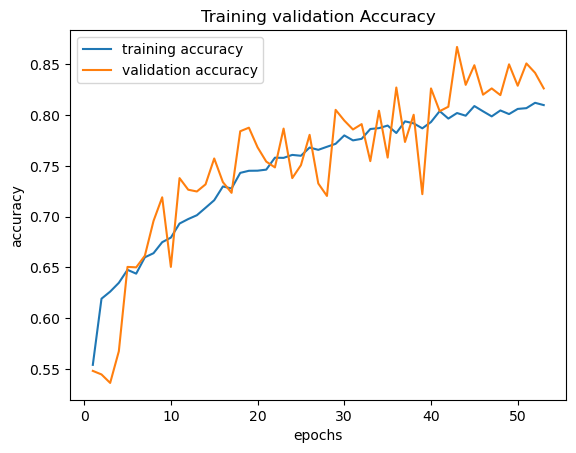

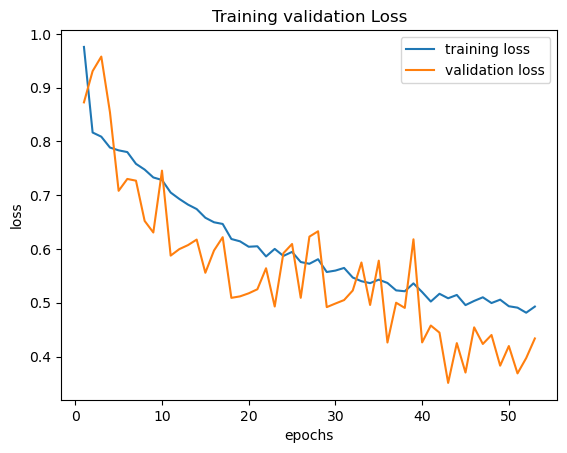

In [10]:
import matplotlib.pyplot as plt
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc)+1)

plt.plot(epochs, acc, label='training accuracy')
plt.plot(epochs, val_acc, label='validation accuracy')
plt.legend()
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.title('Training validation Accuracy')
plt.show()

plt.plot(epochs, loss, label='training loss')
plt.plot(epochs, val_loss, label='validation loss')
plt.legend()
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title('Training validation Loss')
plt.show()

In [1]:
model.evaluate(test_data)

NameError: name 'model' is not defined

In [11]:
model.save('primary_model_1_Jan_2024.h5')

In [11]:
model = tf.keras.models.load_model('primary_model_1_Jan_2024.h5')

In [16]:
import cv2
import matplotlib.pyplot as plt

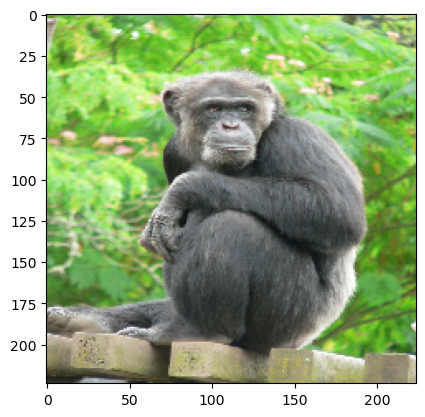

In [32]:
import cv2
import matplotlib.pyplot as plt
img = cv2.imread(r"D:\ZSL\devise-Awa2-october-2022\Test classes\chimpanzee\chimpanzee_10027.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224,224))
img = img/255.0
plt.imshow(img)

In [17]:
img.shape

(224, 224, 3)

In [18]:
input_img = img.reshape(1,224,224,3)
input_img.shape

(1, 224, 224, 3)

In [19]:
output = model.predict(input_img)

1/1 [==============================] - 1s 1s/step


In [20]:
output

array([[0.78854233, 0.20833305, 0.00312462]], dtype=float32)

In [9]:

out = np.argmax(output)
out

0

In [27]:
print(counter_cat)

537


In [28]:
print(counter_hippo_leopard)

0


In [29]:
print(counter_humpback)

15


In [25]:
print(counter_rat_raccoon)

255


In [39]:
print(counter_pig)

204


In [37]:
print(counter_panda)

490


In [13]:
print(counter_seal)

201


In [17]:
print(counter_chimp)

375


In [12]:
full_model_2= tf.keras.models.load_model('ZSL_classification_class_2_1st_jan.h5')

In [13]:
full_model_1 = tf.keras.models.load_model('ZSL_classification_without_Autoencoder_class_1_batch_27_december.h5')

In [14]:
full_model_3 = tf.keras.models.load_model('ZSL_classification_class_3_30_december.h5')

In [ ]:
# #Final classification 


# import time
# t0 = time.time()
# save_pred = {}
# Main_counter_1=0
# Main_counter_2=0
# count_1=0
# count_2=0
# count_3=0
# count_4=0
# count_5=0
# counter_hippo_leopard=0
# counter_cat=0
# counter_humpback=0
# counter_seal=0
# counter_chimp=0
# counter_pig=0
# counter_panda=0
# counter_rat_raccoon=0


# for img_path in glob.glob(r"D:\ZSL\CNN\Test_TRIAL_DATASET_1-CLASS_1\*\*"):




#     img = cv2.imread(img_path)
#     img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#     img = cv2.resize(img, (224,224))
#     img = img/255.0
#     #plt.imshow(img)
#     input_img = img.reshape(1,224,224,3)
#     output = model.predict(input_img)
#     out = np.argmax(output)
#     print('result is =',out)
#     if out == 0:
                    
#             img: np.ndarray = np.asarray(tf.keras.preprocessing.image.load_img(
#             img_path))
#             img =img/255
    
#             prediction: np.ndarray = full_model_1.predict(np.expand_dims((tf.image.resize(img, (224, 224))), axis=0))

#             # get top-n labels by cosine similarity
#             most_similar: List[str] = fast_text_vectors.similar_by_vector(
#             prediction[0], topn=15)
        
    
#             for i in most_similar:
#                 if i[0] == 'bear':
            
#                     counter_panda+=1
                
#             for i in most_similar:
#                # if i[0] == img_path.split("\\")[-2]:
#                 if i[0] == 'chimp':
#                     counter_chimp+=1
            
#             for i in most_similar:
#                 if i[0] == img_path.split("\\")[-2]:
#                     counter_pig+=1
            
                    

#             # display image
#             plt.figure(figsize=(2,2))
#             plt.imshow(img)
#             plt.axis('off')
#             plt.show()

#             # print the predictions for image
#             save_pred[img_path] = [x[0] for x in most_similar]
#             print("foler",img_path)
#             print(f"Prediction for image: {', '.join([x[0] for x in most_similar])}")
#             count_1+=1
            
          
                
            
                               

#     elif out == 1 :       

#             img: np.ndarray = np.asarray(tf.keras.preprocessing.image.load_img(
#             img_path))
#             img =img/255
    
#             prediction: np.ndarray = full_model_2.predict(np.expand_dims((tf.image.resize(img, (224, 224))), axis=0))
    
#             # img: np.ndarray = np.asarray(tf.keras.preprocessing.image.load_img(
#             # img_path))
#             # img =img/255
            
#             # prediction: np.ndarray = model_2_ZSL.predict(np.expand_dims(
#             #     tf.keras.applications.vgg19.preprocess_input(tf.image.resize(
#             #     img, (224, 224))), axis=0))

#             # get top-n labels by cosine similarity
#             most_similar: List[str] = fast_text_vectors.similar_by_vector(
#             prediction[0], topn=30)
        
    
#             for i in most_similar:
#                 if i[0] == img_path.split("\\")[-2]:
               
#                     counter_hippo_leopard+=1
                                    
                
#             for i in most_similar:
#                 if i[0] == img_path.split("\\")[-2]:
#                 # if i[0] == 'racoon':
#                     counter_rat_raccoon+=1
            
#             for i in most_similar:
#                 if i[0] == 'cat':
#                     counter_cat+=1
            
                    

#             # display image
#             plt.figure(figsize=(2,2))
#             plt.imshow(img)
#             plt.axis('off')
#             plt.show()

#             # print the predictions for image
#             save_pred[img_path] = [x[0] for x in most_similar]
#             print("foler",img_path)
#             print(f"Prediction for image: {', '.join([x[0] for x in most_similar])}")
#             count_2+=1

#     else:

#             img: np.ndarray = np.asarray(tf.keras.preprocessing.image.load_img(
#             img_path))
#             img =img/255
    
#             prediction: np.ndarray = full_model_3.predict(np.expand_dims((tf.image.resize(img, (224, 224))), axis=0))

#             # get top-n labels by cosine similarity
#             most_similar: List[str] = fast_text_vectors.similar_by_vector(
#             prediction[0], topn=15)

#             # get top-n labels by cosine similarity
#             most_similar: List[str] = fast_text_vectors.similar_by_vector(
#             prediction[0], topn=20)
        
    
                        
#             for i in most_similar:
#                 if i[0] == 'sealskin':
#             #  if i[0] == 'dog':
#                     counter_seal+=1
                
#             for i in most_similar:
#                # if i[0] == img_path.split("\\")[-2]:
#                 if i[0] == 'humpback':
#                     counter_humpback+=1
                
            
            
                    

#             # display image
#             plt.figure(figsize=(2,2))
#             plt.imshow(img)
#             plt.axis('off')
#             plt.show()

#             # print the predictions for image
#             save_pred[img_path] = [x[0] for x in most_similar]
#             print("foler",img_path)
#             print(f"Prediction for image: {', '.join([x[0] for x in most_similar])}")
#             count_3+=1
            
# print("Testing time:", time.time()-t0)    
        

In [47]:
class_labels = ['cow','gorilla','ox', 'polar_bear', 'spider_monkey', ]

1/1 [==============================] - 0s 26ms/step
result is = 2
1/1 [==============================] - 0s 61ms/step
predicted_label
whale
similar_words_autoencoder : ['humpback whale', 'blue whale', 'killer whale', 'seal', 'dolphin', 'polar_bear', 'walrus', 'cow', 'ox', 'hippopotamus']


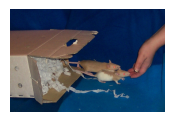

foler D:\ZSL\CNN\Test_TRIAL_DATASET_1-CLASS_1\rat\rat_10001.jpg
Prediction for image: tiger, cat, rabbit, squirrel, lion, dog, raccoon, monkey, bobcat, elephant, racoon, leopard, sabre-tooth, big-cat, beagle, kitten, wolf-dog, stoat, moggie, porcupine, half-dog, housecat, mouse, animal, lionhead, lion-tailed, mouse-deer, rhinoceros, staffy, deer
1/1 [==============================] - 0s 21ms/step
result is = 1
1/1 [==============================] - 0s 66ms/step
predicted_label
cat
similar_words_autoencoder : ['persian cat', 'siamese cat', 'rat', 'monkey', 'pig', 'leopard', 'lion', 'giant panda', 'mouse', 'tiger']


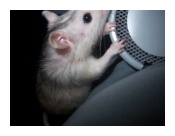

foler D:\ZSL\CNN\Test_TRIAL_DATASET_1-CLASS_1\rat\rat_10002.jpg
Prediction for image: tiger, cat, rabbit, squirrel, lion, dog, raccoon, monkey, bobcat, elephant, racoon, leopard, sabre-tooth, big-cat, beagle, kitten, wolf-dog, stoat, moggie, porcupine, half-dog, housecat, mouse, animal, lionhead, lion-tailed, mouse-deer, rhinoceros, staffy, deer
1/1 [==============================] - 0s 25ms/step
result is = 1
1/1 [==============================] - 0s 64ms/step
predicted_label
cat
similar_words_autoencoder : ['persian cat', 'siamese cat', 'rat', 'monkey', 'pig', 'leopard', 'lion', 'giant panda', 'mouse', 'tiger']


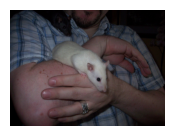

foler D:\ZSL\CNN\Test_TRIAL_DATASET_1-CLASS_1\rat\rat_10003.jpg
Prediction for image: tiger, cat, rabbit, squirrel, lion, dog, raccoon, monkey, bobcat, elephant, racoon, leopard, sabre-tooth, big-cat, beagle, kitten, wolf-dog, stoat, moggie, porcupine, half-dog, housecat, mouse, animal, lionhead, lion-tailed, mouse-deer, rhinoceros, staffy, deer
1/1 [==============================] - 0s 21ms/step
result is = 2
1/1 [==============================] - 0s 49ms/step
predicted_label
dolphin
similar_words_autoencoder : ['whale', 'humpback whale', 'blue whale', 'killer whale', 'walrus', 'polar_bear', 'seal', 'hippopotamus', 'rhinoceros', 'giant panda']


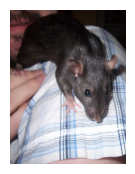

foler D:\ZSL\CNN\Test_TRIAL_DATASET_1-CLASS_1\rat\rat_10004.jpg
Prediction for image: tiger, cat, rabbit, squirrel, lion, dog, raccoon, monkey, bobcat, elephant, racoon, leopard, sabre-tooth, big-cat, beagle, kitten, wolf-dog, stoat, moggie, porcupine, half-dog, housecat, mouse, animal, lionhead, lion-tailed, mouse-deer, rhinoceros, staffy, deer
1/1 [==============================] - 0s 22ms/step
result is = 2
1/1 [==============================] - 0s 47ms/step
predicted_label
dolphin
similar_words_autoencoder : ['whale', 'humpback whale', 'blue whale', 'killer whale', 'walrus', 'polar_bear', 'seal', 'hippopotamus', 'rhinoceros', 'giant panda']


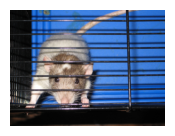

foler D:\ZSL\CNN\Test_TRIAL_DATASET_1-CLASS_1\rat\rat_10005.jpg
Prediction for image: tiger, cat, rabbit, squirrel, lion, dog, raccoon, monkey, bobcat, elephant, racoon, leopard, sabre-tooth, big-cat, beagle, kitten, wolf-dog, stoat, moggie, porcupine, half-dog, housecat, mouse, animal, lionhead, lion-tailed, mouse-deer, rhinoceros, staffy, deer
1/1 [==============================] - 0s 21ms/step
result is = 1
1/1 [==============================] - 0s 70ms/step
predicted_label
cat
similar_words_autoencoder : ['persian cat', 'siamese cat', 'rat', 'monkey', 'pig', 'leopard', 'lion', 'giant panda', 'mouse', 'tiger']


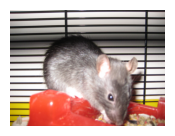

foler D:\ZSL\CNN\Test_TRIAL_DATASET_1-CLASS_1\rat\rat_10006.jpg
Prediction for image: tiger, cat, rabbit, squirrel, lion, dog, raccoon, monkey, bobcat, elephant, racoon, leopard, sabre-tooth, big-cat, beagle, kitten, wolf-dog, stoat, moggie, porcupine, half-dog, housecat, mouse, animal, lionhead, lion-tailed, mouse-deer, rhinoceros, staffy, deer
1/1 [==============================] - 0s 21ms/step
result is = 2
1/1 [==============================] - 0s 55ms/step
predicted_label
whale
similar_words_autoencoder : ['humpback whale', 'blue whale', 'killer whale', 'seal', 'dolphin', 'polar_bear', 'walrus', 'cow', 'ox', 'hippopotamus']


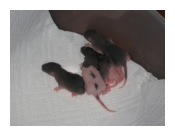

foler D:\ZSL\CNN\Test_TRIAL_DATASET_1-CLASS_1\rat\rat_10007.jpg
Prediction for image: tiger, cat, rabbit, squirrel, lion, dog, raccoon, monkey, bobcat, elephant, racoon, leopard, sabre-tooth, big-cat, beagle, kitten, wolf-dog, stoat, moggie, porcupine, half-dog, housecat, mouse, animal, lionhead, lion-tailed, mouse-deer, rhinoceros, staffy, deer
1/1 [==============================] - 0s 22ms/step
result is = 1
1/1 [==============================] - 0s 71ms/step
predicted_label
cat
similar_words_autoencoder : ['persian cat', 'siamese cat', 'rat', 'monkey', 'pig', 'leopard', 'lion', 'giant panda', 'mouse', 'tiger']


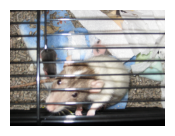

foler D:\ZSL\CNN\Test_TRIAL_DATASET_1-CLASS_1\rat\rat_10008.jpg
Prediction for image: tiger, cat, rabbit, squirrel, lion, dog, raccoon, monkey, bobcat, elephant, racoon, leopard, sabre-tooth, big-cat, beagle, kitten, wolf-dog, stoat, moggie, porcupine, half-dog, housecat, mouse, animal, lionhead, lion-tailed, mouse-deer, rhinoceros, staffy, deer
1/1 [==============================] - 0s 21ms/step
result is = 1
1/1 [==============================] - 0s 65ms/step
predicted_label
cat
similar_words_autoencoder : ['persian cat', 'siamese cat', 'rat', 'monkey', 'pig', 'leopard', 'lion', 'giant panda', 'mouse', 'tiger']


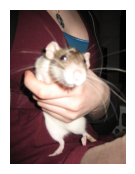

foler D:\ZSL\CNN\Test_TRIAL_DATASET_1-CLASS_1\rat\rat_10009.jpg
Prediction for image: tiger, cat, rabbit, squirrel, lion, dog, raccoon, monkey, bobcat, elephant, racoon, leopard, sabre-tooth, big-cat, beagle, kitten, wolf-dog, stoat, moggie, porcupine, half-dog, housecat, mouse, animal, lionhead, lion-tailed, mouse-deer, rhinoceros, staffy, deer
1/1 [==============================] - 0s 22ms/step
result is = 1
1/1 [==============================] - 0s 65ms/step
predicted_label
tiger
similar_words_autoencoder : ['lion', 'giant panda', 'leopard', 'cat', 'persian cat', 'siamese cat', 'pig', 'ox', 'polar_bear', 'rat']


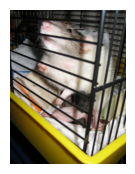

foler D:\ZSL\CNN\Test_TRIAL_DATASET_1-CLASS_1\rat\rat_10010.jpg
Prediction for image: tiger, cat, rabbit, squirrel, lion, dog, raccoon, monkey, bobcat, elephant, racoon, leopard, sabre-tooth, big-cat, beagle, kitten, wolf-dog, stoat, moggie, porcupine, half-dog, housecat, mouse, animal, lionhead, lion-tailed, mouse-deer, rhinoceros, staffy, deer
1/1 [==============================] - 0s 21ms/step
result is = 1
1/1 [==============================] - 0s 64ms/step
predicted_label
cat
similar_words_autoencoder : ['persian cat', 'siamese cat', 'rat', 'monkey', 'pig', 'leopard', 'lion', 'giant panda', 'mouse', 'tiger']


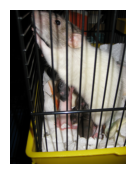

foler D:\ZSL\CNN\Test_TRIAL_DATASET_1-CLASS_1\rat\rat_10011.jpg
Prediction for image: tiger, cat, rabbit, squirrel, lion, dog, raccoon, monkey, bobcat, elephant, racoon, leopard, sabre-tooth, big-cat, beagle, kitten, wolf-dog, stoat, moggie, porcupine, half-dog, housecat, mouse, animal, lionhead, lion-tailed, mouse-deer, rhinoceros, staffy, deer
1/1 [==============================] - 0s 21ms/step
result is = 2
1/1 [==============================] - 0s 46ms/step
predicted_label
dolphin
similar_words_autoencoder : ['whale', 'humpback whale', 'blue whale', 'killer whale', 'walrus', 'polar_bear', 'seal', 'hippopotamus', 'rhinoceros', 'giant panda']


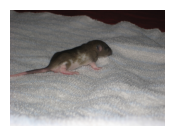

foler D:\ZSL\CNN\Test_TRIAL_DATASET_1-CLASS_1\rat\rat_10012.jpg
Prediction for image: tiger, cat, rabbit, squirrel, lion, dog, raccoon, monkey, bobcat, elephant, racoon, leopard, sabre-tooth, big-cat, beagle, kitten, wolf-dog, stoat, moggie, porcupine, half-dog, housecat, mouse, animal, lionhead, lion-tailed, mouse-deer, rhinoceros, staffy, deer
1/1 [==============================] - 0s 21ms/step
result is = 1
1/1 [==============================] - 0s 75ms/step
predicted_label
cat
similar_words_autoencoder : ['persian cat', 'siamese cat', 'rat', 'monkey', 'pig', 'leopard', 'lion', 'giant panda', 'mouse', 'tiger']


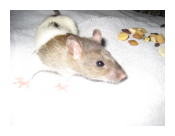

foler D:\ZSL\CNN\Test_TRIAL_DATASET_1-CLASS_1\rat\rat_10013.jpg
Prediction for image: tiger, cat, rabbit, squirrel, lion, dog, raccoon, monkey, bobcat, elephant, racoon, leopard, sabre-tooth, big-cat, beagle, kitten, wolf-dog, stoat, moggie, porcupine, half-dog, housecat, mouse, animal, lionhead, lion-tailed, mouse-deer, rhinoceros, staffy, deer
1/1 [==============================] - 0s 23ms/step
result is = 2
1/1 [==============================] - 0s 47ms/step
predicted_label
whale
similar_words_autoencoder : ['humpback whale', 'blue whale', 'killer whale', 'seal', 'dolphin', 'polar_bear', 'walrus', 'cow', 'ox', 'hippopotamus']


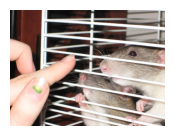

foler D:\ZSL\CNN\Test_TRIAL_DATASET_1-CLASS_1\rat\rat_10014.jpg
Prediction for image: tiger, cat, rabbit, squirrel, lion, dog, raccoon, monkey, bobcat, elephant, racoon, leopard, sabre-tooth, big-cat, beagle, kitten, wolf-dog, stoat, moggie, porcupine, half-dog, housecat, mouse, animal, lionhead, lion-tailed, mouse-deer, rhinoceros, staffy, deer
1/1 [==============================] - 0s 20ms/step
result is = 2
1/1 [==============================] - 0s 49ms/step
predicted_label
walrus
similar_words_autoencoder : ['dolphin', 'hippopotamus', 'bobcat', 'whale', 'humpback whale', 'skunk', 'rhinoceros', 'squirrel', 'raccoon', 'blue whale']


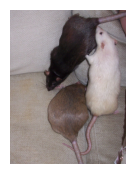

foler D:\ZSL\CNN\Test_TRIAL_DATASET_1-CLASS_1\rat\rat_10015.jpg
Prediction for image: tiger, cat, rabbit, squirrel, lion, dog, raccoon, monkey, bobcat, elephant, racoon, leopard, sabre-tooth, big-cat, beagle, kitten, wolf-dog, stoat, moggie, porcupine, half-dog, housecat, mouse, animal, lionhead, lion-tailed, mouse-deer, rhinoceros, staffy, deer
1/1 [==============================] - 0s 20ms/step
result is = 1
1/1 [==============================] - 0s 63ms/step
predicted_label
rabbit
similar_words_autoencoder : ['rat', 'mouse', 'ox', 'pig', 'cow', 'cat', 'skunk', 'raccoon', 'squirrel', 'persian cat']


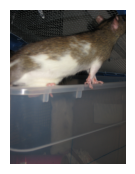

foler D:\ZSL\CNN\Test_TRIAL_DATASET_1-CLASS_1\rat\rat_10016.jpg
Prediction for image: tiger, cat, rabbit, squirrel, lion, dog, raccoon, monkey, bobcat, elephant, racoon, leopard, sabre-tooth, big-cat, beagle, kitten, wolf-dog, stoat, moggie, porcupine, half-dog, housecat, mouse, animal, lionhead, lion-tailed, mouse-deer, rhinoceros, staffy, deer
1/1 [==============================] - 0s 21ms/step
result is = 1
1/1 [==============================] - 0s 64ms/step
predicted_label
tiger
similar_words_autoencoder : ['lion', 'giant panda', 'leopard', 'cat', 'persian cat', 'siamese cat', 'pig', 'ox', 'polar_bear', 'rat']


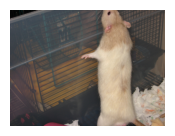

foler D:\ZSL\CNN\Test_TRIAL_DATASET_1-CLASS_1\rat\rat_10017.jpg
Prediction for image: tiger, cat, rabbit, squirrel, lion, dog, raccoon, monkey, bobcat, elephant, racoon, leopard, sabre-tooth, big-cat, beagle, kitten, wolf-dog, stoat, moggie, porcupine, half-dog, housecat, mouse, animal, lionhead, lion-tailed, mouse-deer, rhinoceros, staffy, deer
1/1 [==============================] - 0s 20ms/step
result is = 1
1/1 [==============================] - 0s 63ms/step
predicted_label
cat
similar_words_autoencoder : ['persian cat', 'siamese cat', 'rat', 'monkey', 'pig', 'leopard', 'lion', 'giant panda', 'mouse', 'tiger']


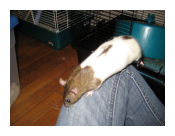

foler D:\ZSL\CNN\Test_TRIAL_DATASET_1-CLASS_1\rat\rat_10018.jpg
Prediction for image: tiger, cat, rabbit, squirrel, lion, dog, raccoon, monkey, bobcat, elephant, racoon, leopard, sabre-tooth, big-cat, beagle, kitten, wolf-dog, stoat, moggie, porcupine, half-dog, housecat, mouse, animal, lionhead, lion-tailed, mouse-deer, rhinoceros, staffy, deer
1/1 [==============================] - 0s 21ms/step
result is = 0
1/1 [==============================] - 0s 52ms/step
predicted_label
monkey
similar_words_autoencoder : ['siamese cat', 'cat', 'squirrel', 'rat', 'persian cat', 'giant panda', 'gorilla', 'chimpanzee', 'mouse', 'tiger', 'pig', 'chimp', 'rabbit', 'lion', 'leopard', 'polar_bear', 'bobcat', 'rhinoceros', 'skunk', 'raccoon']
rat


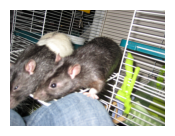

foler D:\ZSL\CNN\Test_TRIAL_DATASET_1-CLASS_1\rat\rat_10019.jpg
Prediction for image: tiger, cat, rabbit, squirrel, lion, dog, raccoon, monkey, bobcat, elephant, racoon, leopard, sabre-tooth, big-cat, beagle, kitten, wolf-dog, stoat, moggie, porcupine, half-dog, housecat, mouse, animal, lionhead, lion-tailed, mouse-deer, rhinoceros, staffy, deer
1/1 [==============================] - 0s 22ms/step
result is = 2
1/1 [==============================] - 0s 49ms/step
predicted_label
dolphin
similar_words_autoencoder : ['whale', 'humpback whale', 'blue whale', 'killer whale', 'walrus', 'polar_bear', 'seal', 'hippopotamus', 'rhinoceros', 'giant panda']


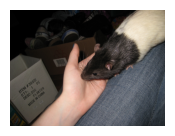

foler D:\ZSL\CNN\Test_TRIAL_DATASET_1-CLASS_1\rat\rat_10020.jpg
Prediction for image: tiger, cat, rabbit, squirrel, lion, dog, raccoon, monkey, bobcat, elephant, racoon, leopard, sabre-tooth, big-cat, beagle, kitten, wolf-dog, stoat, moggie, porcupine, half-dog, housecat, mouse, animal, lionhead, lion-tailed, mouse-deer, rhinoceros, staffy, deer
1/1 [==============================] - 0s 26ms/step
result is = 1
1/1 [==============================] - 0s 74ms/step
predicted_label
cat
similar_words_autoencoder : ['persian cat', 'siamese cat', 'rat', 'monkey', 'pig', 'leopard', 'lion', 'giant panda', 'mouse', 'tiger']


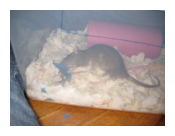

foler D:\ZSL\CNN\Test_TRIAL_DATASET_1-CLASS_1\rat\rat_10021.jpg
Prediction for image: tiger, cat, rabbit, squirrel, lion, dog, raccoon, monkey, bobcat, elephant, racoon, leopard, sabre-tooth, big-cat, beagle, kitten, wolf-dog, stoat, moggie, porcupine, half-dog, housecat, mouse, animal, lionhead, lion-tailed, mouse-deer, rhinoceros, staffy, deer
1/1 [==============================] - 0s 21ms/step
result is = 2
1/1 [==============================] - 0s 53ms/step
predicted_label
walrus
similar_words_autoencoder : ['dolphin', 'hippopotamus', 'bobcat', 'whale', 'humpback whale', 'skunk', 'rhinoceros', 'squirrel', 'raccoon', 'blue whale']


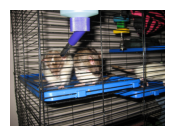

foler D:\ZSL\CNN\Test_TRIAL_DATASET_1-CLASS_1\rat\rat_10022.jpg
Prediction for image: tiger, cat, rabbit, squirrel, lion, dog, raccoon, monkey, bobcat, elephant, racoon, leopard, sabre-tooth, big-cat, beagle, kitten, wolf-dog, stoat, moggie, porcupine, half-dog, housecat, mouse, animal, lionhead, lion-tailed, mouse-deer, rhinoceros, staffy, deer
1/1 [==============================] - 0s 21ms/step
result is = 0
1/1 [==============================] - 0s 57ms/step
predicted_label
monkey
similar_words_autoencoder : ['siamese cat', 'cat', 'squirrel', 'rat', 'persian cat', 'giant panda', 'gorilla', 'chimpanzee', 'mouse', 'tiger', 'pig', 'chimp', 'rabbit', 'lion', 'leopard', 'polar_bear', 'bobcat', 'rhinoceros', 'skunk', 'raccoon']
rat


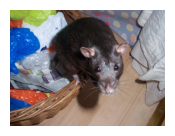

foler D:\ZSL\CNN\Test_TRIAL_DATASET_1-CLASS_1\rat\rat_10023.jpg
Prediction for image: tiger, cat, rabbit, squirrel, lion, dog, raccoon, monkey, bobcat, elephant, racoon, leopard, sabre-tooth, big-cat, beagle, kitten, wolf-dog, stoat, moggie, porcupine, half-dog, housecat, mouse, animal, lionhead, lion-tailed, mouse-deer, rhinoceros, staffy, deer
1/1 [==============================] - 0s 21ms/step
result is = 1
1/1 [==============================] - 0s 69ms/step
predicted_label
cat
similar_words_autoencoder : ['persian cat', 'siamese cat', 'rat', 'monkey', 'pig', 'leopard', 'lion', 'giant panda', 'mouse', 'tiger']


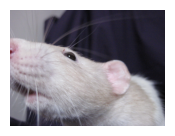

foler D:\ZSL\CNN\Test_TRIAL_DATASET_1-CLASS_1\rat\rat_10024.jpg
Prediction for image: tiger, cat, rabbit, squirrel, lion, dog, raccoon, monkey, bobcat, elephant, racoon, leopard, sabre-tooth, big-cat, beagle, kitten, wolf-dog, stoat, moggie, porcupine, half-dog, housecat, mouse, animal, lionhead, lion-tailed, mouse-deer, rhinoceros, staffy, deer
1/1 [==============================] - 0s 29ms/step
result is = 1
1/1 [==============================] - 0s 67ms/step
predicted_label
tiger
similar_words_autoencoder : ['lion', 'giant panda', 'leopard', 'cat', 'persian cat', 'siamese cat', 'pig', 'ox', 'polar_bear', 'rat']


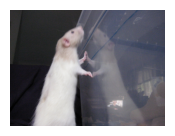

foler D:\ZSL\CNN\Test_TRIAL_DATASET_1-CLASS_1\rat\rat_10025.jpg
Prediction for image: tiger, cat, rabbit, squirrel, lion, dog, raccoon, monkey, bobcat, elephant, racoon, leopard, sabre-tooth, big-cat, beagle, kitten, wolf-dog, stoat, moggie, porcupine, half-dog, housecat, mouse, animal, lionhead, lion-tailed, mouse-deer, rhinoceros, staffy, deer
1/1 [==============================] - 0s 21ms/step
result is = 1
1/1 [==============================] - 0s 67ms/step
predicted_label
cat
similar_words_autoencoder : ['persian cat', 'siamese cat', 'rat', 'monkey', 'pig', 'leopard', 'lion', 'giant panda', 'mouse', 'tiger']


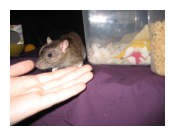

foler D:\ZSL\CNN\Test_TRIAL_DATASET_1-CLASS_1\rat\rat_10026.jpg
Prediction for image: tiger, cat, rabbit, squirrel, lion, dog, raccoon, monkey, bobcat, elephant, racoon, leopard, sabre-tooth, big-cat, beagle, kitten, wolf-dog, stoat, moggie, porcupine, half-dog, housecat, mouse, animal, lionhead, lion-tailed, mouse-deer, rhinoceros, staffy, deer


KeyboardInterrupt: 

In [21]:
#Final classification 


import time
t0 = time.time()
save_pred = {}
Main_counter_1=0
Main_counter_2=0
count_1=0
count_2=0
count_3=0
count_4=0
count_5=0
counter_hippo_leopard=0
counter_cat=0
counter_humpback=0
counter_seal=0
counter_chimp=0
counter_pig=0
counter_panda=0
counter_rat_raccoon=0
Autoencoder_counter_chimpanzee = 0
Autoencoder_counter_persian_cat = 0
Autoencoder_counter=0


for img_path in glob.glob(r"D:\ZSL\CNN\Test_TRIAL_DATASET_1-CLASS_1\*\*"):




    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224,224))
    img = img/255.0
    #plt.imshow(img)
    input_img = img.reshape(1,224,224,3)
    output = model.predict(input_img)
    out = np.argmax(output)
    print('result is =',out)
    if out == 0:
                    
            img: np.ndarray = np.asarray(tf.keras.preprocessing.image.load_img(
            img_path))
            img =img/255
    
            prediction: np.ndarray = full_model_1.predict(np.expand_dims((tf.image.resize(img, (224, 224))), axis=0))

            ranked_neighbors = fast_text_vectors.most_similar(positive=[prediction[0]])
            top_hit = ranked_neighbors[0][0]

            print("predicted_label")
            print(top_hit)

            similar_words_autoencoder = predict_with_autoencoder(custom_sentences.index(top_hit), sentence_to_latent, top_n=20) # class_labels
            print(f"similar_words_autoencoder : {similar_words_autoencoder}")
            # print(img_path.split("\\")[-2])
            
            # for i in similar_words_autoencoder:
            #     if 'chimpanzee' in i:  # Check if 'chimpanzee' is part of the tuple/list element
            #          Autoencoder_counter_chimpanzee += 1

            # print("Autoencoder_counter_chimpanzee")
            # print(Autoencoder_counter_chimpanzee)
            
            # for i in similar_words_autoencoder:
            #     if 'persian cat' in i:  # Check if 'chimpanzee' is part of the tuple/list element
            #          Autoencoder_counter_persian_cat += 1

            for i in similar_words_autoencoder:
                 if (img_path.split("\\")[-2]) in i:  # Check if 'chimpanzee' is part of the tuple/list element
                      Autoencoder_counter += 1
                      print(img_path.split("\\")[-2])

            # most_similar: List[str] = fast_text_vectors.similar_by_vector(
            # prediction[0], topn=15)

            # # print("prediction[0]")
            # # print(prediction[0])
        
    
            # for i in most_similar:
            #     if i[0] == 'bear':
            
            #         counter_panda+=1
                
            # for i in most_similar:
            #    # if i[0] == img_path.split("\\")[-2]:
            #     if i[0] == 'chimp':
            #         counter_chimp+=1
            
            # for i in most_similar:
            #     if i[0] == img_path.split("\\")[-2]:
            #         counter_pig+=1
            
                    

            # display image
            plt.figure(figsize=(2,2))
            plt.imshow(img)
            plt.axis('off')
            plt.show()

            # print the predictions for image
            save_pred[img_path] = [x[0] for x in most_similar]
            print("foler",img_path)
            print(f"Prediction for image: {', '.join([x[0] for x in most_similar])}")
            count_1+=1
            
          
                
            
                               

    elif out == 1 :       

            img: np.ndarray = np.asarray(tf.keras.preprocessing.image.load_img(
            img_path))
            img =img/255
    
            prediction: np.ndarray = full_model_2.predict(np.expand_dims((tf.image.resize(img, (224, 224))), axis=0))
    
            ranked_neighbors = fast_text_vectors.most_similar(positive=[prediction[0]])
            top_hit = ranked_neighbors[0][0]

            print("predicted_label")
            print(top_hit)

            similar_words_autoencoder = predict_with_autoencoder(custom_sentences.index(top_hit), sentence_to_latent, top_n=10) # class_labels
            print(f"similar_words_autoencoder : {similar_words_autoencoder}")
            # print(img_path.split("\\")[-2])

            # for i in similar_words_autoencoder:
            #     if 'persian cat' in i:  # Check if 'chimpanzee' is part of the tuple/list element
            #          Autoencoder_counter_persian_cat += 1
            for i in similar_words_autoencoder:
                 if (img_path.split("\\")[-2]) in i:  # Check if 'chimpanzee' is part of the tuple/list element
                      Autoencoder_counter += 1
                      

            # most_similar: List[str] = fast_text_vectors.similar_by_vector(
            # prediction[0], topn=30)
        
    
            # for i in most_similar:
            #     if i[0] == img_path.split("\\")[-2]:
               
            #         counter_hippo_leopard+=1
                                    
                
            # for i in most_similar:
            #     if i[0] == img_path.split("\\")[-2]:
            #     # if i[0] == 'racoon':
            #         counter_rat_raccoon+=1
            
            # for i in most_similar:
            #     if i[0] == 'cat':
            #         counter_cat+=1
            
                    

            # display image
            plt.figure(figsize=(2,2))
            plt.imshow(img)
            plt.axis('off')
            plt.show()

            # print the predictions for image
            save_pred[img_path] = [x[0] for x in most_similar]
            print("foler",img_path)
            print(f"Prediction for image: {', '.join([x[0] for x in most_similar])}")
            count_2+=1

    else:

            img: np.ndarray = np.asarray(tf.keras.preprocessing.image.load_img(
            img_path))
            img =img/255
    
            prediction: np.ndarray = full_model_3.predict(np.expand_dims((tf.image.resize(img, (224, 224))), axis=0))

            ranked_neighbors = fast_text_vectors.most_similar(positive=[prediction[0]])
            top_hit = ranked_neighbors[0][0]

            print("predicted_label")
            print(top_hit)

            if (top_hit=="blue"):
                 top_hit = "whale"

            similar_words_autoencoder = predict_with_autoencoder(custom_sentences.index(top_hit), sentence_to_latent, top_n=10) # class_labels
            print(f"similar_words_autoencoder : {similar_words_autoencoder}")
            # print(img_path.split("\\")[-2])

            for i in similar_words_autoencoder:
                 if (img_path.split("\\")[-2]) in i:  # Check if 'chimpanzee' is part of the tuple/list element
                      Autoencoder_counter += 1
                      


            # # get top-n labels by cosine similarity
            # most_similar: List[str] = fast_text_vectors.similar_by_vector(
            # prediction[0], topn=15)

            # # get top-n labels by cosine similarity
            # most_similar: List[str] = fast_text_vectors.similar_by_vector(
            # prediction[0], topn=20)
        
    
                        
            # for i in most_similar:
            #     if i[0] == 'sealskin':
            # #  if i[0] == 'dog':
            #         counter_seal+=1
                
            # for i in most_similar:
            #    # if i[0] == img_path.split("\\")[-2]:
            #     if i[0] == 'humpback':
            #         counter_humpback+=1
                
            
            
                    

            # display image
            plt.figure(figsize=(2,2))
            plt.imshow(img)
            plt.axis('off')
            plt.show()

            # print the predictions for image
            save_pred[img_path] = [x[0] for x in most_similar]
            print("foler",img_path)
            print(f"Prediction for image: {', '.join([x[0] for x in most_similar])}")
            count_3+=1
            
print("Testing time:", time.time()-t0)    
print(Autoencoder_counter)       

In [29]:
print("Autoencoder_counter_chimpanzee")
print(Autoencoder_counter_chimpanzee)

Autoencoder_counter_chimpanzee
350


In [31]:
print("fasttext_counter_chimpanzee")
print(counter_chimp)

fasttext_counter_chimpanzee
350


In [35]:
print("Autoencoder_counter_persian_cat")
print(Autoencoder_counter_persian_cat)

Autoencoder_counter_persian_cat
543


In [ ]:
print("fasttext_counter_cat")
print(counter_cat)

In [22]:
print(Autoencoder_counter)    

17


In [54]:
print(counter_panda)

3


In [28]:
print(counter_cat)

503


In [30]:
print(counter_rat_raccoon)

253


In [47]:
print(counter_seal)

0


In [20]:
print(counter_chimp)

374


In [15]:
print(counter_panda)

121


In [10]:
print(counter_pig)

133


In [23]:
counter_hippo_leopard

628

In [10]:
counter_humpback

382

In [31]:
count_1

202

In [32]:
count_2

253

In [33]:
count_3

57

In [3]:
batch_size = 4
img_height = 224
img_width = 224

In [4]:
train_data=tf.keras.utils.image_dataset_from_directory(r"D:\ZSL\devise-Awa2-october-2022\ZSL_class_21_may\class_1",labels="inferred",
  label_mode="int",
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(r"D:\ZSL\devise-Awa2-october-2022\ZSL_class_21_may\class_1",labels="inferred",
  label_mode="int",
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 4097 files belonging to 5 classes.
Using 3278 files for training.
Found 4097 files belonging to 5 classes.
Using 819 files for validation.


In [6]:
lenth_train_data = len(train_data.file_paths)
lenth_val_data = len(val_ds.file_paths)
lenth_train_data,  lenth_val_data

(6408, 1601)

In [7]:
class_names = train_data.class_names
print(class_names)

['blue_whale', 'bobcat', 'dolphin', 'killer_whale', 'lion', 'mouse', 'rabbit', 'rhinoceros', 'siamese+cat', 'skunk', 'squirrel', 'tiger', 'walrus']


In [8]:
x_l=[]
y_l = []
for x,y in train_data:
  x_l.append(x)
  y_l.append(y)
x_train=np.concatenate(x_l,axis=0)
y_train =np.concatenate(y_l,axis=0)


In [9]:
x_l=[]
y_l = []
for x,y in val_ds:
  x_l.append(x)
  y_l.append(y)
val_dat=np.concatenate(x_l,axis=0)
y_test =np.concatenate(y_l,axis=0)

In [10]:
fine_labels: List[str] = class_names
fine_labels

['blue_whale',
 'bobcat',
 'dolphin',
 'killer_whale',
 'lion',
 'mouse',
 'rabbit',
 'rhinoceros',
 'siamese+cat',
 'skunk',
 'squirrel',
 'tiger',
 'walrus']

In [11]:
y_train = np.reshape(y_train,(lenth_train_data,1))
y_test = np.reshape(y_test,(lenth_val_data,1))

In [12]:
y_train_str: np.ndarray = np.array(list(map(lambda x: np.array(
    [fine_labels[x[0]]]), y_train)))
y_test_str: np.ndarray = np.array(list(map(lambda x: np.array(
    [fine_labels[x[0]]]), y_test)))

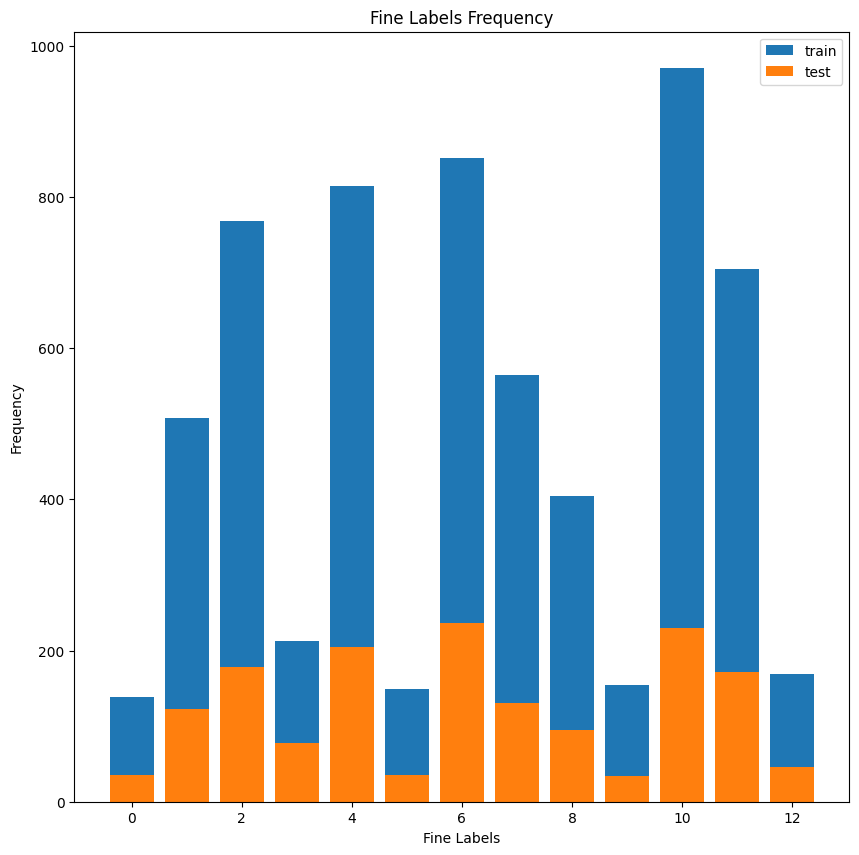

In [13]:
unique: np.ndarray = None
counts: int = 0

plt.figure(figsize=(10, 10))
unique, counts = np.unique(y_train, return_counts=True)
plt.bar(unique, counts, label='train')
unique, counts = np.unique(y_test, return_counts=True)
plt.bar(unique, counts, label='test')

plt.title('Fine Labels Frequency')
plt.xlabel('Fine Labels')
plt.ylabel('Frequency')

plt.legend()
plt.show()

In [18]:
import gensim as gs

import gensim.downloader as gdownloader

In [21]:
fast_text_vectors: gs.models.keyedvectors = gdownloader.load(
     "fasttext-wiki-news-subwords-300")

In [19]:
from gensim.models.keyedvectors import KeyedVectors
# fast_text_vectors.save('fstwk.d2v')
fast_text_vectors = KeyedVectors.load("fstwk.d2v")

In [51]:
fine_labels_words: List[List[str]] = list(
    map(tf.keras.preprocessing.text.text_to_word_sequence, fine_labels))

word_list: List[str] = None
for word_list in fine_labels_words:
    print(word_list)

NameError: name 'fine_labels' is not defined

In [26]:
word_list: List[str] = None
word: str = ''
for word_list in fine_labels_words:
    for word in word_list:
        try:
            fast_text_vectors.word_vec(word)
        except Exception as err:
            print(f"-----{word} isn't in corpus----")

C:\Users\91932\miniconda3\envs\zero_short_learning_gpu\lib\site-packages\ipykernel_launcher.py:6: DeprecationWarning: Call to deprecated `word_vec` (Use get_vector instead).
  


In [27]:
def word_list_to_avg_vector(lst: List[str]) -> np.ndarray:
    """
    Transform a word list to its average vector
    Parameters:
        lst (List[str]): string to transform to vector
    Returns:
        np.ndarray: vector representation of word list
    """
    # create empty array
    vec: np.ndarray = np.array([0.0] * 300)

    word: str = ''
    for word in lst:
        # add word vector to sentence vectors or zero if no word vector
        vec += fast_text_vectors.word_vec(word)

    # return average vector (take sentence length into consideration)
    return vec / len(lst)


fine_labels_vecs = np.asarray(list(
    map(word_list_to_avg_vector, fine_labels_words)))

print(f"fine labels vectors shape: {fine_labels_vecs.shape}")

fine labels vectors shape: (13, 300)


C:\Users\91932\miniconda3\envs\zero_short_learning_gpu\lib\site-packages\ipykernel_launcher.py:15: DeprecationWarning: Call to deprecated `word_vec` (Use get_vector instead).
  from ipykernel import kernelapp as app


In [28]:
# calculate cosine similarity between each two labels
similarity_matrix: np.ndarray = skpairwise.cosine_similarity(
    fine_labels_vecs, fine_labels_vecs)

# get only lower triangle
similarity_matrix: np.ndarray = np.tril(similarity_matrix, -1)

# get indexes with cosine similarity greater than 0.65
indexes: np.ndarray = np.argwhere(similarity_matrix > 0.5)

# create dataframe for better printing
fine_labels_high_similarity: pd.DataFrame = pd.DataFrame(
    {'Fine Label 1': [fine_labels[i[0]] for i in indexes],
     'Fine Label 2':  [fine_labels[i[1]] for i in indexes],
     'cosine similarity': [similarity_matrix[i[0], i[1]] for i in indexes]
     }
)

print("Fine labels with high cosine"
      "similarity and the cosine similarity value:\n"
      f"{fine_labels_high_similarity}")

Fine labels with high cosinesimilarity and the cosine similarity value:
    Fine Label 1  Fine Label 2  cosine similarity
0        dolphin    blue_whale           0.679589
1   killer_whale    blue_whale           0.806770
2   killer_whale       dolphin           0.701142
3           lion    blue_whale           0.529450
4           lion       dolphin           0.524764
5           lion  killer_whale           0.517552
6         rabbit         mouse           0.607289
7     rhinoceros    blue_whale           0.506983
8     rhinoceros  killer_whale           0.518046
9     rhinoceros          lion           0.565613
10   siamese+cat        bobcat           0.563919
11   siamese+cat          lion           0.520759
12   siamese+cat         mouse           0.575225
13   siamese+cat        rabbit           0.613360
14         skunk        bobcat           0.529458
15         skunk   siamese+cat           0.510126
16      squirrel    blue_whale           0.528626
17      squirrel        bobc

In [29]:
y_train_vecs: np.ndarray = np.asarray(
    [fine_labels_vecs[label] for label in y_train])
y_train_vecs: np.ndarray = y_train_vecs.reshape((lenth_train_data, 300))
y_test_vecs: np.ndarray = np.asarray(
    [fine_labels_vecs[label] for label in y_test])
y_test_vecs: np.ndarray = y_test_vecs.reshape((lenth_val_data, 300))

print(f"Train fine labels vectors shape: {y_train_vecs.shape}")
print(f"Test fine labels vectors shape: {y_test_vecs.shape}")

Train fine labels vectors shape: (6408, 300)
Test fine labels vectors shape: (1601, 300)


In [30]:
x_train: np.ndarray = tf.keras.applications.vgg19.preprocess_input(x_train)
val_dat: np.ndarray = tf.keras.applications.vgg19.preprocess_input(val_dat)

In [7]:
# create base model = vgg19
#base_model: tf.keras.Model = tf.keras.applications.VGG19(
  #  weights='imagenet', include_top=False, 
   # input_shape=(224, 224, 3), pooling='max')
# freeze the base_model so it will not train

#base_model=DenseNet121(weights='imagenet',include_top=False, input_shape=(224, 224, 3)) 

base_model= tf.keras.applications.ResNet50(include_top=False,
                   input_shape=(224,224,3),
                   pooling='max',
                   weights='imagenet')
# from keras.models import Model

#model2 = Model(base_model.input, base_model.layers[-2].output)
base_model.summary()
base_model.trainable = False


Model: "resnet50"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                           

                                                                                                  
 conv3_block3_1_relu (Activatio  (None, 28, 28, 128)  0          ['conv3_block3_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv3_block3_2_conv (Conv2D)   (None, 28, 28, 128)  147584      ['conv3_block3_1_relu[0][0]']    
                                                                                                  
 conv3_block3_2_bn (BatchNormal  (None, 28, 28, 128)  512        ['conv3_block3_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv3_block3_2_relu (Activatio  (None, 28, 28, 128)  0          ['conv3_block3_2_bn[0][0]']      
 n)       

                                                                                                  
 conv4_block2_1_bn (BatchNormal  (None, 14, 14, 256)  1024       ['conv4_block2_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv4_block2_1_relu (Activatio  (None, 14, 14, 256)  0          ['conv4_block2_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv4_block2_2_conv (Conv2D)   (None, 14, 14, 256)  590080      ['conv4_block2_1_relu[0][0]']    
                                                                                                  
 conv4_block2_2_bn (BatchNormal  (None, 14, 14, 256)  1024       ['conv4_block2_2_conv[0][0]']    
 ization) 

 conv4_block5_1_conv (Conv2D)   (None, 14, 14, 256)  262400      ['conv4_block4_out[0][0]']       
                                                                                                  
 conv4_block5_1_bn (BatchNormal  (None, 14, 14, 256)  1024       ['conv4_block5_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv4_block5_1_relu (Activatio  (None, 14, 14, 256)  0          ['conv4_block5_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv4_block5_2_conv (Conv2D)   (None, 14, 14, 256)  590080      ['conv4_block5_1_relu[0][0]']    
                                                                                                  
 conv4_blo

                                                                  'conv5_block1_3_bn[0][0]']      
                                                                                                  
 conv5_block1_out (Activation)  (None, 7, 7, 2048)   0           ['conv5_block1_add[0][0]']       
                                                                                                  
 conv5_block2_1_conv (Conv2D)   (None, 7, 7, 512)    1049088     ['conv5_block1_out[0][0]']       
                                                                                                  
 conv5_block2_1_bn (BatchNormal  (None, 7, 7, 512)   2048        ['conv5_block2_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv5_block2_1_relu (Activatio  (None, 7, 7, 512)   0           ['conv5_block2_1_bn[0][0]']      
 n)       

In [32]:


# create new model
model: tf.keras.Model = tf.keras.models.Sequential()
# add input layer
model.add(tf.keras.Input(shape=(224,224,3)))
# add augmentation layers
model.add(tf.keras.layers.experimental.preprocessing.RandomFlip("horizontal"))
model.add(tf.keras.layers.experimental.preprocessing.RandomRotation(0.1))
# add base model
model.add(base_model)
# add new layers to train
model.add(tf.keras.layers.Dense(448, activation='relu'))
model.add(tf.keras.layers.Dropout(0.5))
model.add(tf.keras.layers.Dense(384, activation='relu'))
model.add(tf.keras.layers.Dropout(0.5))
model.add(tf.keras.layers.Dense(300))
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 random_flip_1 (RandomFlip)  (None, 224, 224, 3)       0         
                                                                 
 random_rotation_1 (RandomRo  (None, 224, 224, 3)      0         
 tation)                                                         
                                                                 
 resnet50 (Functional)       (None, 2048)              23587712  
                                                                 
 dense_3 (Dense)             (None, 448)               917952    
                                                                 
 dropout_2 (Dropout)         (None, 448)               0         
                                                                 
 dense_4 (Dense)             (None, 384)               172416    
                                                      

In [33]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
              loss=tf.keras.losses.CosineSimilarity(axis=1))

In [34]:
import time

In [25]:
t0 = time.time()

es: tf.keras.callbacks.EarlyStopping = tf.keras.callbacks.EarlyStopping(
   monitor="val_loss", min_delta=0.01, patience=6, mode="min",
    restore_best_weights=True)
history: tf.keras.callbacks.History = model.fit(
    x_train, y_train_vecs, epochs=20, shuffle=True, 
    batch_size=batch_size, validation_split=0.2, callbacks=[es])

print("Training time:", time.time()-t0)

Epoch 1/20
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
656/656 [==============================] - ETA: 0s - loss: -0.8809WARNING:tensorflow:AutoGraph could not transform <function Model.make_test_function.<locals>.test_function at 0x000002263B96F9D8> and will run it as-is.
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the f

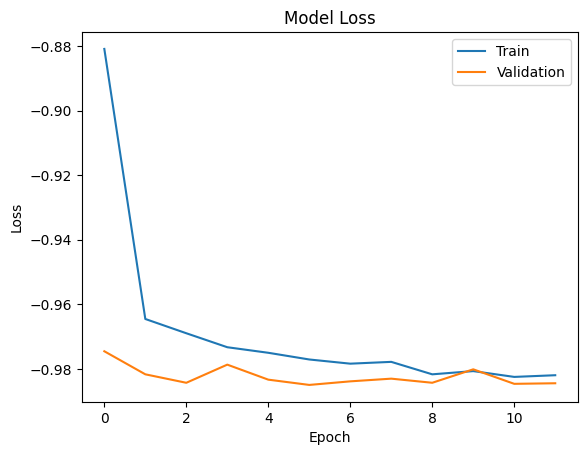

In [29]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

In [27]:
# batch generator for large data 

In [35]:
class My_Custom_Generator(keras.utils.Sequence) :
  
    def __init__(self, images, labels, batch_size) :
        self.images = images
        self.labels = labels
        self.batch_size = batch_size


    def __len__(self) :
        
        return (np.ceil(len(self.images) / float(self.batch_size))).astype(np.int)


    def __getitem__(self, idx) :
        
        batch_x = self.images[idx * self.batch_size : (idx+1) * self.batch_size]
        batch_y = self.labels[idx * self.batch_size : (idx+1) * self.batch_size]

        return np.array(batch_x), np.array(batch_y)

In [36]:
batch_size = 4
my_training_batch_generator = My_Custom_Generator(x_train, y_train_vecs, batch_size)
my_validation_batch_generator = My_Custom_Generator(val_dat, y_test_vecs, batch_size)

In [38]:
t0 = time.time()

es: tf.keras.callbacks.EarlyStopping = tf.keras.callbacks.EarlyStopping(
   monitor="val_loss", min_delta=0.01, patience=6, mode="min",
    restore_best_weights=True)
history: tf.keras.callbacks.History = model.fit(
    my_training_batch_generator, epochs=50, shuffle=True, 
    validation_data = my_validation_batch_generator,steps_per_epoch = int(3800 // batch_size),batch_size=batch_size,validation_steps = int(950 // batch_size), callbacks=[es])
print("Training time:", time.time()-t0)

C:\Users\91932\miniconda3\envs\zero_short_learning_gpu\lib\site-packages\ipykernel_launcher.py:11: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  # This is added back by InteractiveShellApp.init_path()


Epoch 1/50
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
950/950 [==============================] - ETA: 0s - loss: -0.8340WARNING:tensorflow:AutoGraph could not transform <function Model.make_test_function.<locals>.test_function at 0x0000024F89170AF8> and will run it as-is.
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the f

In [28]:
model.save('21_may_main_class_2_ZSL_model.h5')

In [27]:
model.save('21_may_main_class_1_ZSL_model.h5')

In [5]:
model_1_ZSL = tf.keras.models.load_model('ZSL_classification_without_Autoencoder_class_1_batch_27_december.h5')

In [10]:
model_2_ZSL = tf.keras.models.load_model(r"D:\ZSL\october-2022\ZSL_classification_class_2_29_december.h5")

In [6]:
model_3_ZSL = tf.keras.models.load_model('ZSL_classification_class_3_30_december.h5')

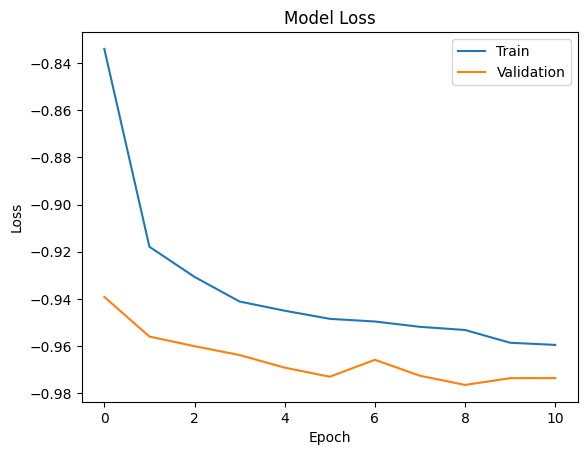

In [39]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

In [276]:
model_eval: float = model.evaluate(val_dat, y_test_vecs) 
print(f"Model loss {model_eval}")

3/3 [==============================] - 3s 332ms/step - loss: -0.9974
Model loss -0.9973796606063843
